# CS3807 – Deep Learning Laboratory
## Experiment 7: End-to-End Study of Autoencoders, Convolutional Autoencoders, Denoising Autoencoders and Variational Autoencoders

**Dataset:** MNIST  
**Recommended laboratory subset:** 10,000 training images + 2,000 test images  


## 1. Experiment objectives

This notebook implements the complete pipeline:

**MNIST → normalization → encoder → latent representation → decoder → reconstruction → evaluation**

and additionally:

**Clean image → noise → denoising autoencoder → recovered image**

and:

**Image → (μ, log σ²) → reparameterized z → decoder → reconstructed/generated image**

The experiment includes:
1. Fully Connected Autoencoder
2. Convolutional Autoencoder
3. Denoising Convolutional Autoencoder
4. Variational Autoencoder
5. Reconstruction metrics: MSE, MAE, SSIM
6. Latent-space visualization
7. VAE generation and interpolation
8. Reconstruction-error distribution and top-5 high-error samples
9. Latent-dimension study: 2, 8, 16, 32
10. Additional exercises: CAE latent dimensions, noise-type comparison, noise-level comparison, transposed-convolution decoder, VAE latent dimensions, KL weighting, larger generated grids

In [ ]:
# ============================================================
# 2. INSTALL / IMPORT REQUIRED LIBRARIES
# ============================================================
!pip -q install scikit-image

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim
from IPython.display import display

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# 3. LOAD AND PREPARE MNIST
# ============================================================
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

# Recommended subset from the experiment sheet
N_TRAIN = 10_000
N_TEST = 2_000

x_train = x_train_full[:N_TRAIN].astype("float32") / 255.0
x_test = x_test_full[:N_TEST].astype("float32") / 255.0

y_train = y_train_full[:N_TRAIN]
y_test = y_test_full[:N_TEST]

# Add channel dimension
x_train_img = np.expand_dims(x_train, -1)
x_test_img = np.expand_dims(x_test, -1)

print("Training images:", x_train_img.shape)
print("Test images:", x_test_img.shape)
print("Pixel range:", x_train_img.min(), "to", x_train_img.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (10000, 28, 28, 1)
Test images: (2000, 28, 28, 1)
Pixel range: 0.0 to 1.0


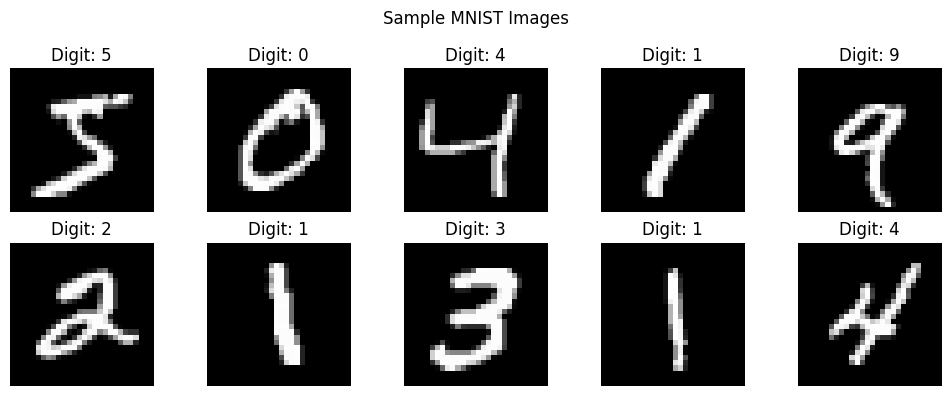

In [ ]:
# Visualize sample MNIST images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(x_train_img[i].squeeze(), cmap="gray")
    ax.set_title(f"Digit: {y_train[i]}")
    ax.axis("off")
plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

## 4. Utility functions

These functions are reused throughout the experiment for:
- MSE
- MAE
- mean SSIM
- parameter counting
- reconstruction visualization
- loss plotting
- per-image reconstruction error

In [ ]:
# ============================================================
# 4. UTILITY FUNCTIONS
# ============================================================
def calculate_metrics(original, reconstructed):
    original = np.asarray(original)
    reconstructed = np.asarray(reconstructed)

    mse_value = np.mean((original - reconstructed) ** 2)
    mae_value = np.mean(np.abs(original - reconstructed))

    ssim_values = []
    for i in range(len(original)):
        a = np.squeeze(original[i])
        b = np.squeeze(reconstructed[i])
        ssim_values.append(ssim(a, b, data_range=1.0))

    return {
        "MSE": float(mse_value),
        "MAE": float(mae_value),
        "SSIM": float(np.mean(ssim_values))
    }


def per_image_mse(original, reconstructed):
    return np.mean((original - reconstructed) ** 2, axis=(1, 2, 3))


def plot_reconstructions(original, reconstructed, n=10, title="Original vs Reconstruction"):
    n = min(n, len(original))
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(original[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("Original")

        axes[1, i].imshow(reconstructed[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")
        axes[1, i].set_title("Reconstruction")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_loss(history, title="Training and Validation Loss", metric_name="loss"):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[metric_name], label="Training")
    if f"val_{metric_name}" in history.history:
        plt.plot(history.history[f"val_{metric_name}"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def count_parameters(model):
    return model.count_params()


def make_results_row(name, model, original, reconstructed, training_time=None):
    metrics = calculate_metrics(original, reconstructed)
    return {
        "Model": name,
        "MSE": metrics["MSE"],
        "MAE": metrics["MAE"],
        "SSIM": metrics["SSIM"],
        "Parameters": model.count_params(),
        "Time (sec)": training_time
    }

# Part A – Fully Connected Autoencoder

Required architecture:

**784 → 128 → 32 → 16 → 32 → 128 → 784**

Hidden activation: ReLU  
Output activation: Sigmoid  
Optimizer: Adam  
Learning rate: 1e-3  
Batch size: 128  
Epochs: 20  
Loss: Binary Cross-Entropy

In [ ]:
# ============================================================
# 5. FULLY CONNECTED AUTOENCODER
# ============================================================
LATENT_DIM_FC = 16

fc_encoder = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(LATENT_DIM_FC, name="latent")
], name="FC_Encoder")

fc_decoder = keras.Sequential([
    layers.Input(shape=(LATENT_DIM_FC,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid")
], name="FC_Decoder")

fc_autoencoder = keras.Sequential([
    fc_encoder,
    fc_decoder
], name="Fully_Connected_Autoencoder")

fc_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

fc_autoencoder.summary()

Model: "Fully_Connected_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ FC_Encoder (Sequential)         │ (None, 16)             │       105,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC_Decoder (Sequential)         │ (None, 784)            │       105,904 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 6. TRAIN FULLY CONNECTED AUTOENCODER
# ============================================================
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

start_time = time.time()

history_fc = fc_autoencoder.fit(
    x_train_flat,
    x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=1
)

fc_time = time.time() - start_time
print(f"Training time: {fc_time:.2f} seconds")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - loss: 0.3416 - val_loss: 0.2485
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.2229 - val_loss: 0.1985
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1904 - val_loss: 0.1822
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1732 - val_loss: 0.1673
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1607 - val_loss: 0.1585
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1529 - val_loss: 0.1524
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1474 - val_loss: 0.1476
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1429 - val_loss: 0.1436
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1393 - val_loss: 0.1405
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1364 - val_loss: 0.1381
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1340 - val_loss: 0.1359
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1319 - val

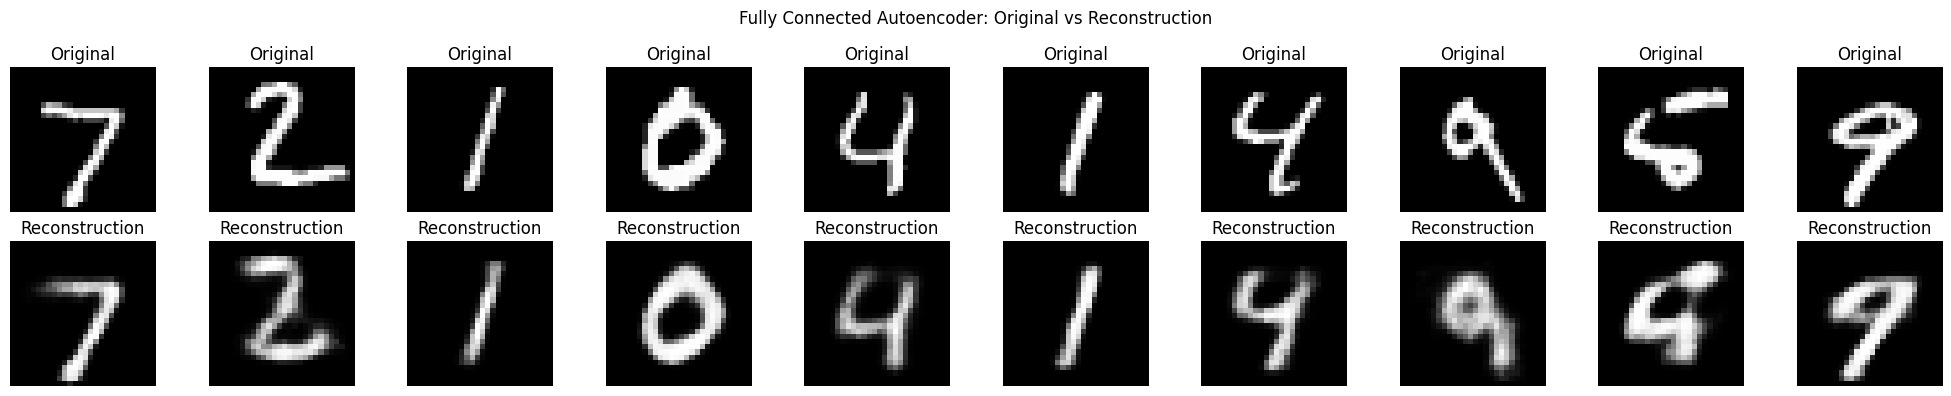

In [ ]:
# ============================================================
# 7. PLOT 1 – FC-AE RECONSTRUCTIONS
# ============================================================
fc_recon_flat = fc_autoencoder.predict(x_test_flat, verbose=0)
fc_recon = fc_recon_flat.reshape(-1, 28, 28, 1)

plot_reconstructions(
    x_test_img,
    fc_recon,
    n=10,
    title="Fully Connected Autoencoder: Original vs Reconstruction"
)

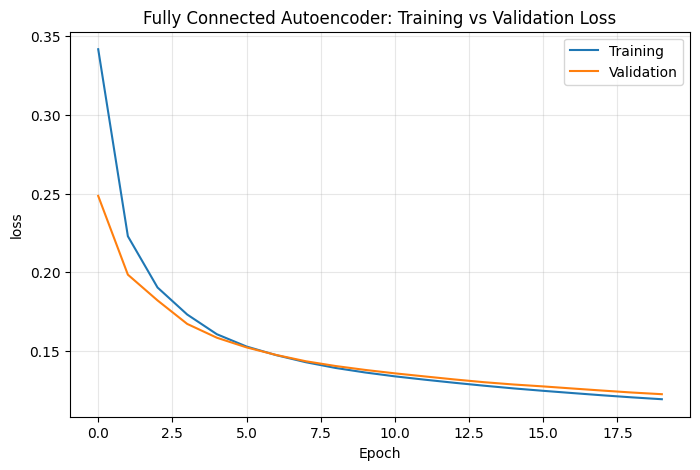

Final training loss: 0.11946319788694382
Final validation loss: 0.12265390157699585


In [ ]:
# ============================================================
# 8. PLOT 2 – FC-AE TRAINING / VALIDATION LOSS
# ============================================================
plot_loss(
    history_fc,
    title="Fully Connected Autoencoder: Training vs Validation Loss"
)

print("Final training loss:", history_fc.history["loss"][-1])
print("Final validation loss:", history_fc.history["val_loss"][-1])

In [ ]:
# ============================================================
# 9. FC-AE METRICS
# ============================================================
fc_metrics = calculate_metrics(x_test_img, fc_recon)
fc_metrics_df = pd.DataFrame([fc_metrics], index=["Fully Connected AE"])
display(fc_metrics_df)

,MSE,MAE,SSIM
Fully Connected AE,0.020513,0.054925,0.756392


### Required inference – basic autoencoder

Use the generated plots and metrics to comment on:
- preservation of digit shape
- loss of fine details
- blurred regions
- easy vs difficult samples
- convergence
- possible overfitting

The cell below creates a report-ready prompt using your actual final losses.

In [ ]:
# Auto-generated observations to help write the report
train_final = history_fc.history["loss"][-1]
val_final = history_fc.history["val_loss"][-1]

print(f"Final training BCE:   {train_final:.6f}")
print(f"Final validation BCE: {val_final:.6f}")
print(f"Validation - training gap: {val_final - train_final:.6f}")

if val_final > train_final * 1.20:
    print("Observation: validation loss is noticeably higher than training loss; inspect for overfitting.")
else:
    print("Observation: training and validation losses are relatively close; strong overfitting is not obvious.")

print("Visual observation should be added after inspecting Plot 1.")

Final training BCE:   0.119463
Final validation BCE: 0.122654
Validation - training gap: 0.003191
Observation: training and validation losses are relatively close; strong overfitting is not obvious.
Visual observation should be added after inspecting Plot 1.


# Part B – Convolutional Autoencoder

Architecture from the experiment sheet:

- Conv2D(32, 3×3, ReLU, same)
- MaxPooling2D(2, same)
- Conv2D(64, 3×3, ReLU, same)
- MaxPooling2D(2, same)
- Conv2D(64, 3×3, ReLU, same)
- UpSampling2D(2)
- Conv2D(32, 3×3, ReLU, same)
- UpSampling2D(2)
- Conv2D(1, 3×3, Sigmoid, same)

In [ ]:
# ============================================================
# 10. CONVOLUTIONAL AUTOENCODER
# ============================================================
def build_cae(latent_channels=64):
    inputs = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)

    x = layers.Conv2D(latent_channels, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)

    x = layers.Conv2D(latent_channels, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D(2)(x)
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    return keras.Model(inputs, outputs, name=f"CAE_{latent_channels}")

cae = build_cae(64)
cae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)
cae.summary()

Model: "CAE_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 11. TRAIN CAE
# ============================================================
start_time = time.time()

history_cae = cae.fit(
    x_train_img,
    x_train_img,
    validation_data=(x_test_img, x_test_img),
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=1
)

cae_time = time.time() - start_time
print(f"Training time: {cae_time:.2f} seconds")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.2463 - val_loss: 0.1027
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0924 - val_loss: 0.0838
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0829 - val_loss: 0.0786
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0791 - val_loss: 0.0756
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0762 - val_loss: 0.0739
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0746 - val_loss: 0.0727
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0736 - val_loss: 0.0717
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0726 - val_loss: 0.0707
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0718 - val_loss: 0.0701
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0714 - val_loss: 0.0697
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0707 - val_loss: 0.0691
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0704 - val

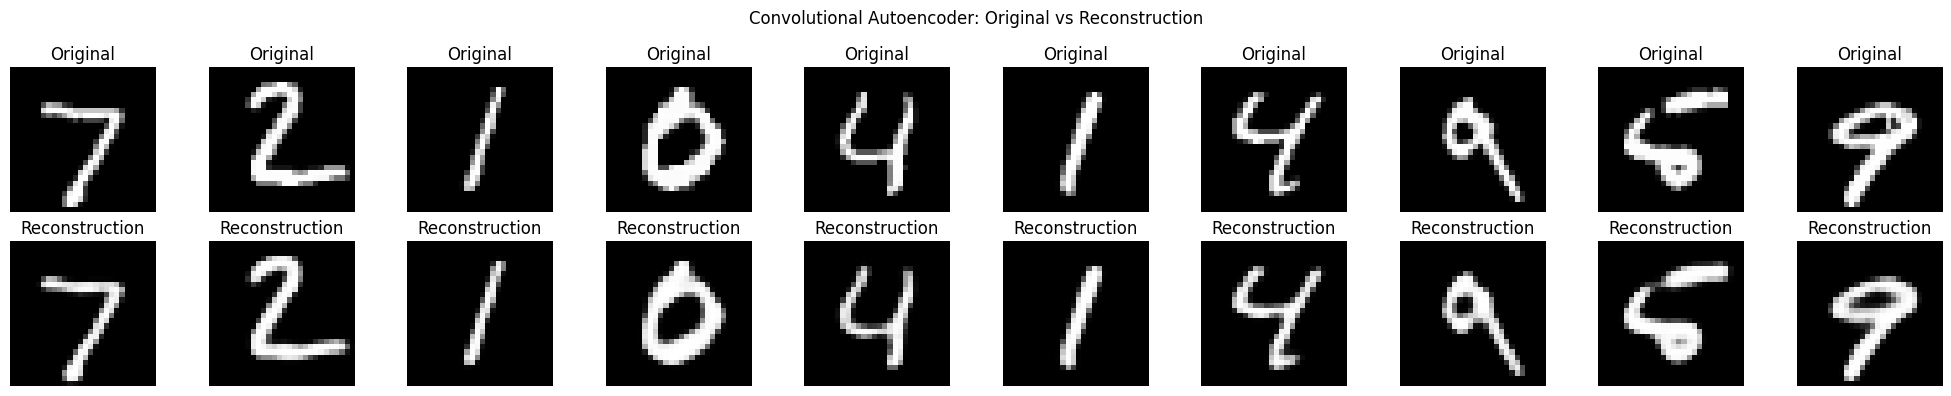

,MSE,MAE,SSIM
Convolutional AE,0.0025,0.014853,0.974801


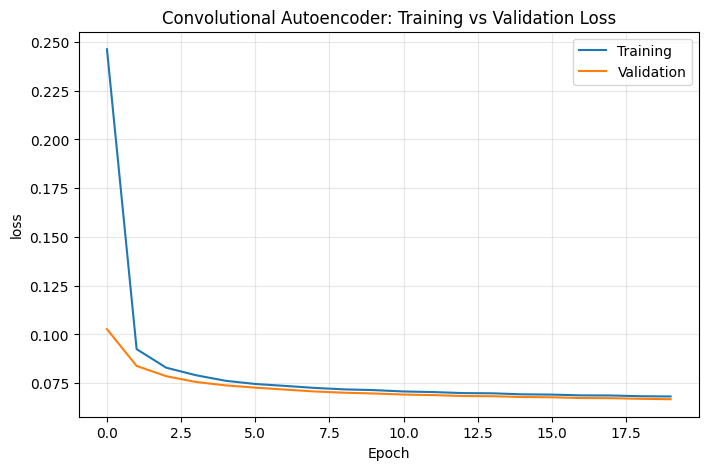

In [ ]:
# ============================================================
# 12. CAE RECONSTRUCTION + METRICS
# ============================================================
cae_recon = cae.predict(x_test_img, verbose=0)

plot_reconstructions(
    x_test_img,
    cae_recon,
    n=10,
    title="Convolutional Autoencoder: Original vs Reconstruction"
)

cae_metrics = calculate_metrics(x_test_img, cae_recon)
display(pd.DataFrame([cae_metrics], index=["Convolutional AE"]))

plot_loss(
    history_cae,
    title="Convolutional Autoencoder: Training vs Validation Loss"
)

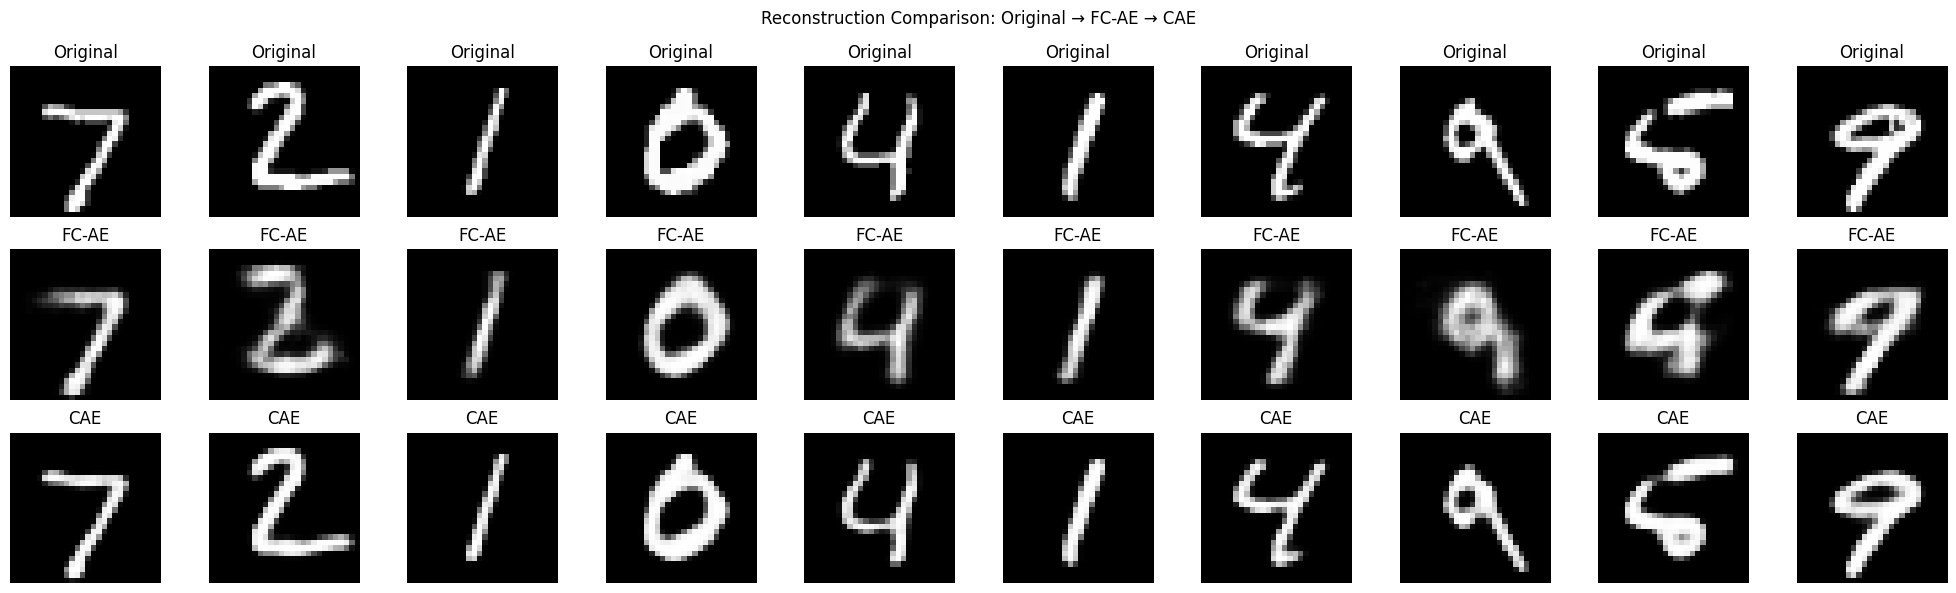

In [ ]:
# ============================================================
# 13. PLOT 3 – FC-AE VS CAE
# ============================================================
n = 10
fig, axes = plt.subplots(3, n, figsize=(2*n, 6))

for i in range(n):
    axes[0, i].imshow(x_test_img[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    axes[1, i].imshow(fc_recon[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("FC-AE")

    axes[2, i].imshow(cae_recon[i].squeeze(), cmap="gray")
    axes[2, i].axis("off")
    axes[2, i].set_title("CAE")

plt.suptitle("Reconstruction Comparison: Original → FC-AE → CAE")
plt.tight_layout()
plt.show()

### Required inference

Compare the FC-AE and CAE visually and quantitatively.

Focus on the role of spatial locality: fully connected layers flatten the image, while convolutional layers process local spatial patterns using shared filters.

In [ ]:
# Quantitative FC-AE vs CAE comparison
comparison_basic = pd.DataFrame([
    make_results_row("Fully Connected AE", fc_autoencoder, x_test_img, fc_recon, fc_time),
    make_results_row("Convolutional AE", cae, x_test_img, cae_recon, cae_time)
])

display(comparison_basic)

,Model,MSE,MAE,SSIM,Parameters,Time (sec)
0,Fully Connected AE,0.020513,0.054925,0.756392,211040,29.089839
1,Convolutional AE,0.002500,0.014853,0.974801,74497,20.866997


# Part C – Denoising Convolutional Autoencoder

The denoising model receives a corrupted image but uses the **clean image as the target**.

Two corruption types are implemented:
1. Gaussian noise with σ = 0.1, 0.2, 0.3
2. Salt-and-pepper noise with p = 0.05, 0.10, 0.20

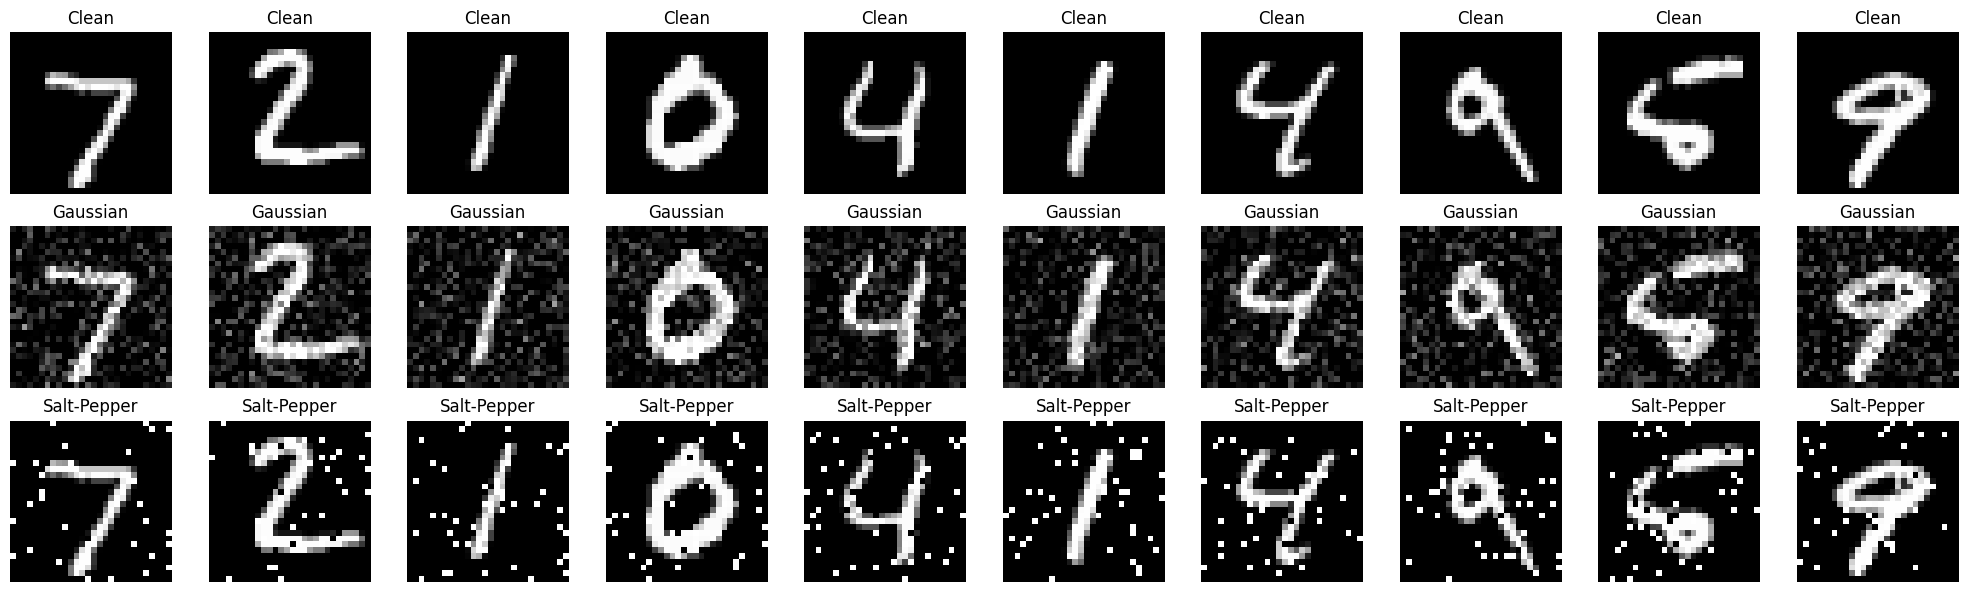

In [ ]:
# ============================================================
# 14. NOISE FUNCTIONS
# ============================================================
def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(0, sigma, images.shape)
    return np.clip(noisy, 0.0, 1.0).astype("float32")


def add_salt_pepper_noise(images, p):
    noisy = images.copy()
    random_matrix = np.random.rand(*images.shape)

    noisy[random_matrix < p / 2] = 0.0
    noisy[(random_matrix >= p / 2) & (random_matrix < p)] = 1.0

    return noisy.astype("float32")


# Demonstrate both noise types
sample_clean = x_test_img[:10]
sample_gaussian = add_gaussian_noise(sample_clean, 0.2)
sample_sp = add_salt_pepper_noise(sample_clean, 0.10)

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i in range(10):
    axes[0, i].imshow(sample_clean[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Clean")
    axes[0, i].axis("off")

    axes[1, i].imshow(sample_gaussian[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Gaussian")
    axes[1, i].axis("off")

    axes[2, i].imshow(sample_sp[i].squeeze(), cmap="gray")
    axes[2, i].set_title("Salt-Pepper")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 15. TRAIN DENOISING CAE WITH GAUSSIAN NOISE
# ============================================================
GAUSSIAN_SIGMA_TRAIN = 0.2

x_train_noisy = add_gaussian_noise(x_train_img, GAUSSIAN_SIGMA_TRAIN)
x_test_noisy = add_gaussian_noise(x_test_img, GAUSSIAN_SIGMA_TRAIN)

denoise_cae = build_cae(64)
denoise_cae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

start_time = time.time()

history_denoise = denoise_cae.fit(
    x_train_noisy,
    x_train_img,  # IMPORTANT: clean target
    validation_data=(x_test_noisy, x_test_img),
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=1
)

denoise_time = time.time() - start_time
print(f"Denoising CAE training time: {denoise_time:.2f} seconds")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.2479 - val_loss: 0.1207
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1069 - val_loss: 0.0961
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0937 - val_loss: 0.0891
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0889 - val_loss: 0.0856
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0859 - val_loss: 0.0832
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0838 - val_loss: 0.0815
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0823 - val_loss: 0.0801
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0811 - val_loss: 0.0791
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0802 - val_loss: 0.0784
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0794 - val_loss: 0.0780
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0788 - val_loss: 0.0776
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0783 - val_l

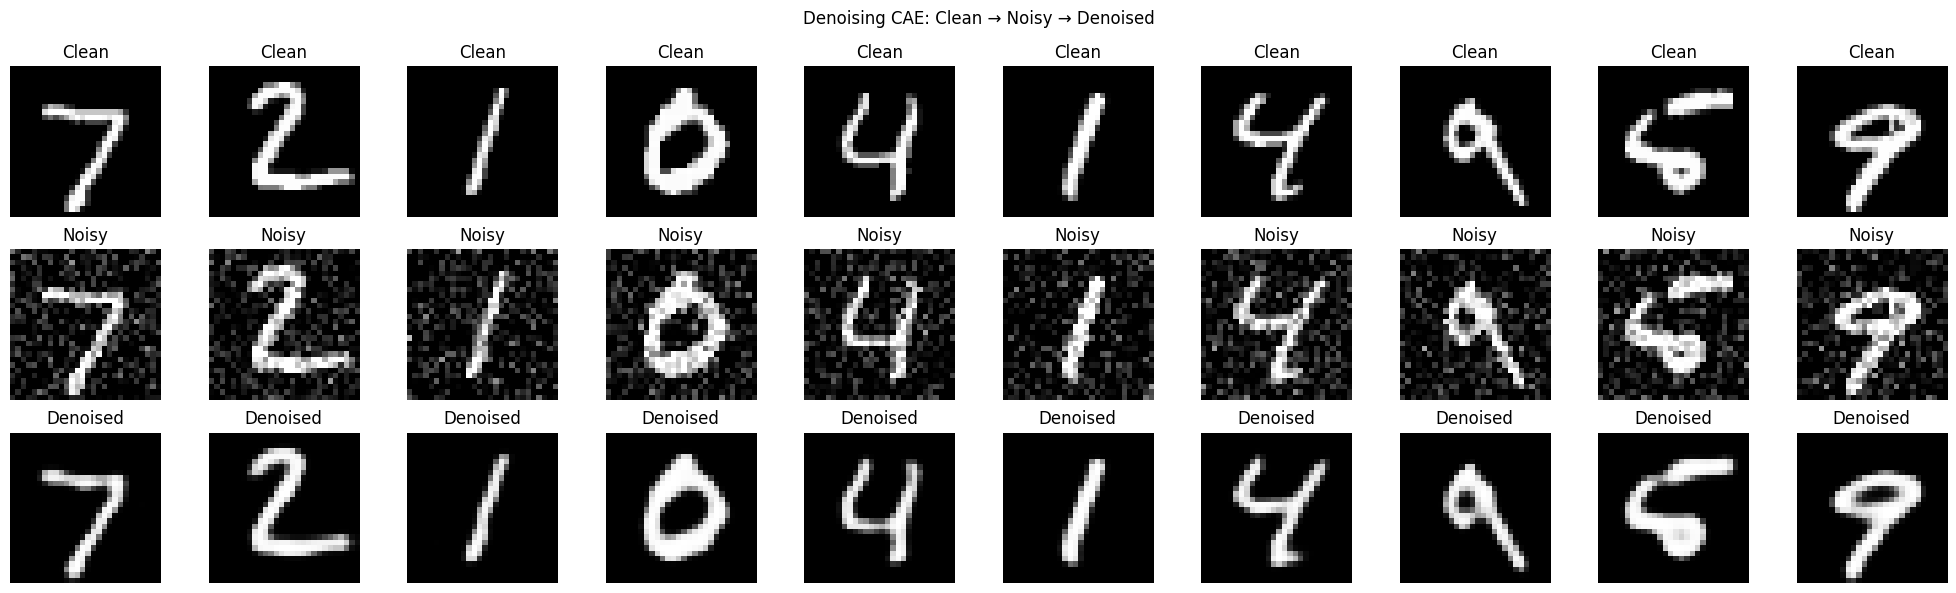

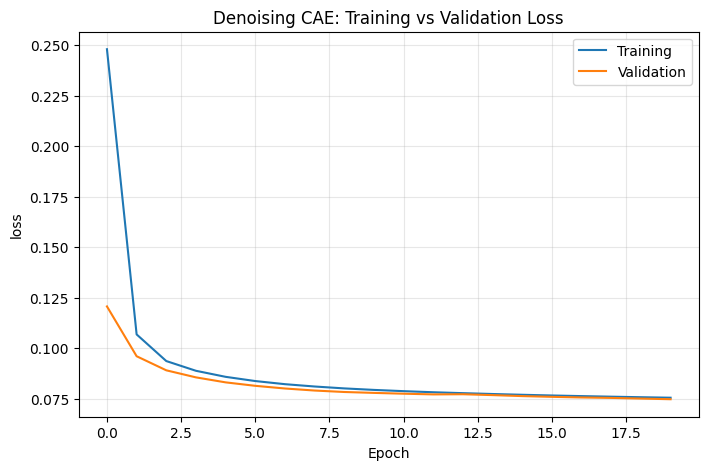

In [ ]:
# ============================================================
# 16. PLOT 4 – CLEAN VS NOISY VS DENOISED
# ============================================================
denoised_recon = denoise_cae.predict(x_test_noisy, verbose=0)

n = 10
fig, axes = plt.subplots(3, n, figsize=(2*n, 6))

for i in range(n):
    axes[0, i].imshow(x_test_img[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Clean")
    axes[0, i].axis("off")

    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Noisy")
    axes[1, i].axis("off")

    axes[2, i].imshow(denoised_recon[i].squeeze(), cmap="gray")
    axes[2, i].set_title("Denoised")
    axes[2, i].axis("off")

plt.suptitle("Denoising CAE: Clean → Noisy → Denoised")
plt.tight_layout()
plt.show()

plot_loss(
    history_denoise,
    title="Denoising CAE: Training vs Validation Loss"
)

In [ ]:
# ============================================================
# 17. DENOISING METRICS AT MULTIPLE GAUSSIAN NOISE LEVELS
# ============================================================
gaussian_levels = [0.1, 0.2, 0.3]
gaussian_results = []

for sigma in gaussian_levels:
    noisy_test = add_gaussian_noise(x_test_img, sigma)
    recon = denoise_cae.predict(noisy_test, verbose=0)
    metrics = calculate_metrics(x_test_img, recon)

    gaussian_results.append({
        "Gaussian Sigma": sigma,
        "MSE": metrics["MSE"],
        "MAE": metrics["MAE"],
        "SSIM": metrics["SSIM"]
    })

gaussian_results_df = pd.DataFrame(gaussian_results)
display(gaussian_results_df)

,Gaussian Sigma,MSE,MAE,SSIM
0,0.1,0.004002,0.018694,0.957502
1,0.2,0.004984,0.021911,0.941646
2,0.3,0.007500,0.030453,0.854348


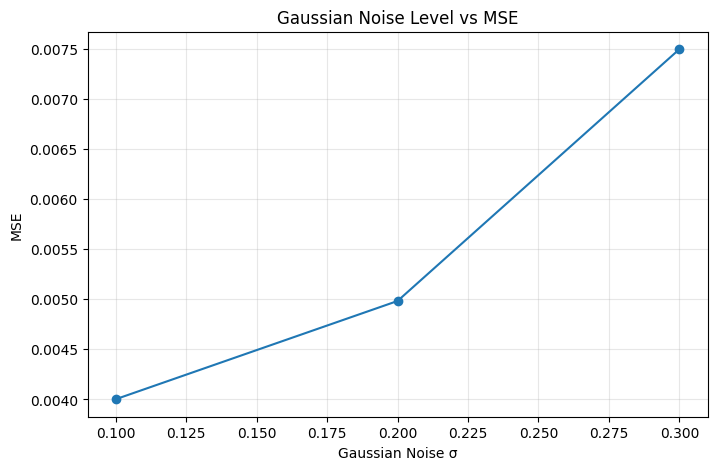

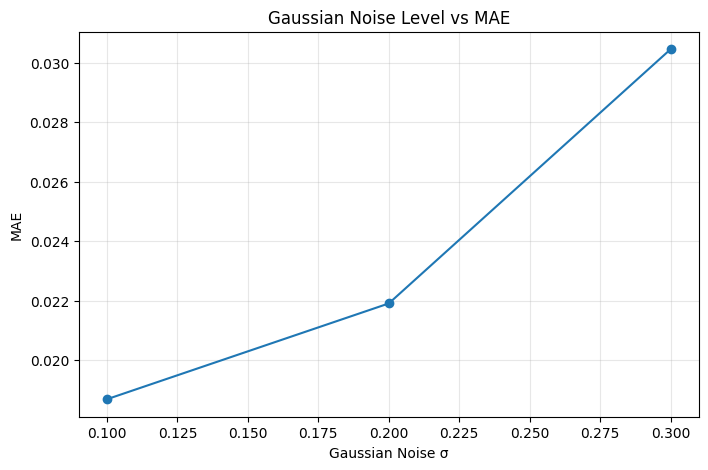

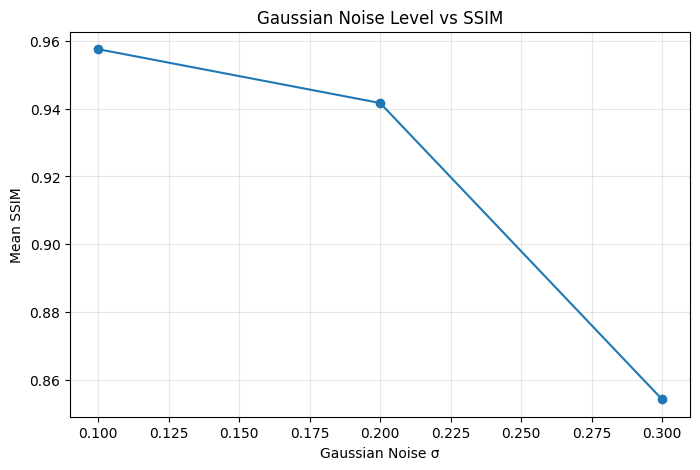

In [ ]:
# Plot 5 – Noise level vs reconstruction quality
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gaussian_results_df["Gaussian Sigma"], gaussian_results_df["MSE"], marker="o")
ax.set_xlabel("Gaussian Noise σ")
ax.set_ylabel("MSE")
ax.set_title("Gaussian Noise Level vs MSE")
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gaussian_results_df["Gaussian Sigma"], gaussian_results_df["MAE"], marker="o")
ax.set_xlabel("Gaussian Noise σ")
ax.set_ylabel("MAE")
ax.set_title("Gaussian Noise Level vs MAE")
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gaussian_results_df["Gaussian Sigma"], gaussian_results_df["SSIM"], marker="o")
ax.set_xlabel("Gaussian Noise σ")
ax.set_ylabel("Mean SSIM")
ax.set_title("Gaussian Noise Level vs SSIM")
ax.grid(alpha=0.3)
plt.show()

### Salt-and-pepper denoising comparison

In [ ]:
# ============================================================
# 18. ADDITIONAL NOISE-TYPE STUDY – SALT AND PEPPER
# ============================================================
sp_levels = [0.05, 0.10, 0.20]
sp_results = []

# Train a model specifically on salt-and-pepper corruption
sp_train_noisy = add_salt_pepper_noise(x_train_img, 0.10)
sp_test_noisy = add_salt_pepper_noise(x_test_img, 0.10)

sp_denoise_cae = build_cae(64)
sp_denoise_cae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

start_time = time.time()
history_sp = sp_denoise_cae.fit(
    sp_train_noisy,
    x_train_img,
    validation_data=(sp_test_noisy, x_test_img),
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=1
)
sp_time = time.time() - start_time

for p in sp_levels:
    noisy_test = add_salt_pepper_noise(x_test_img, p)
    recon = sp_denoise_cae.predict(noisy_test, verbose=0)
    metrics = calculate_metrics(x_test_img, recon)

    sp_results.append({
        "Salt-Pepper p": p,
        "MSE": metrics["MSE"],
        "MAE": metrics["MAE"],
        "SSIM": metrics["SSIM"]
    })

sp_results_df = pd.DataFrame(sp_results)
display(sp_results_df)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.2429 - val_loss: 0.1236
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1062 - val_loss: 0.0944
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0925 - val_loss: 0.0884
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0881 - val_loss: 0.0867
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0856 - val_loss: 0.0845
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0838 - val_loss: 0.0830
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0824 - val_loss: 0.0815
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0813 - val_loss: 0.0802
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0804 - val_loss: 0.0793
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0796 - val_loss: 0.0785
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0790 - val_loss: 0.0779
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0784 - val_l

,Salt-Pepper p,MSE,MAE,SSIM
0,0.05,0.003881,0.018580,0.958538
1,0.10,0.004772,0.020922,0.946044
2,0.20,0.007787,0.028341,0.889635


In [ ]:
# Compare Gaussian and salt-and-pepper at their strongest tested corruption
gaussian_strong = gaussian_results_df.iloc[-1]
sp_strong = sp_results_df.iloc[-1]

noise_type_comparison = pd.DataFrame([
    {
        "Noise": "Gaussian",
        "Level": gaussian_strong["Gaussian Sigma"],
        "MSE": gaussian_strong["MSE"],
        "MAE": gaussian_strong["MAE"],
        "SSIM": gaussian_strong["SSIM"]
    },
    {
        "Noise": "Salt-and-Pepper",
        "Level": sp_strong["Salt-Pepper p"],
        "MSE": sp_strong["MSE"],
        "MAE": sp_strong["MAE"],
        "SSIM": sp_strong["SSIM"]
    }
])
display(noise_type_comparison)

,Noise,Level,MSE,MAE,SSIM
0,Gaussian,0.3,0.007500,0.030453,0.854348
1,Salt-and-Pepper,0.2,0.007787,0.028341,0.889635


# Part D – Variational Autoencoder

The VAE uses a **2-dimensional latent space**, as required.

The encoder produces:
- μ ∈ R²
- log σ² ∈ R²

Reparameterization:

**z = μ + σ ⊙ ε**, where **ε ~ N(0, I)**

VAE loss:

**L_VAE = L_reconstruction + L_KL**

with:

**L_KL = -1/2 Σ(1 + log σ² - μ² - σ²)**

In [ ]:
# ============================================================
# 19. VAE MODEL
# ============================================================
class VAE(keras.Model):
    def __init__(self, latent_dim=2, kl_weight=1.0, name="VAE", **kwargs):
        super().__init__(name=name, **kwargs)
        self.latent_dim = latent_dim
        self.kl_weight = kl_weight

        # Encoder
        self.encoder_conv1 = layers.Conv2D(
            32, 3, strides=2, activation="relu", padding="same"
        )
        self.encoder_conv2 = layers.Conv2D(
            64, 3, strides=2, activation="relu", padding="same"
        )
        self.encoder_flatten = layers.Flatten()
        self.encoder_dense = layers.Dense(128, activation="relu")
        self.z_mean_layer = layers.Dense(latent_dim, name="z_mean")
        self.z_log_var_layer = layers.Dense(latent_dim, name="z_log_var")

        # Decoder
        self.decoder_dense = layers.Dense(7 * 7 * 64, activation="relu")
        self.decoder_reshape = layers.Reshape((7, 7, 64))
        self.decoder_deconv1 = layers.Conv2DTranspose(
            64, 3, strides=2, activation="relu", padding="same"
        )
        self.decoder_deconv2 = layers.Conv2DTranspose(
            32, 3, strides=2, activation="relu", padding="same"
        )
        self.decoder_output = layers.Conv2D(
            1, 3, activation="sigmoid", padding="same"
        )

        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def encode(self, x, training=False):
        x = self.encoder_conv1(x, training=training)
        x = self.encoder_conv2(x, training=training)
        x = self.encoder_flatten(x)
        x = self.encoder_dense(x, training=training)

        z_mean = self.z_mean_layer(x)
        z_log_var = self.z_log_var_layer(x)

        return z_mean, z_log_var

    def reparameterize(self, z_mean, z_log_var):
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        sigma = tf.exp(0.5 * z_log_var)
        return z_mean + sigma * epsilon

    def decode(self, z, training=False):
        x = self.decoder_dense(z, training=training)
        x = self.decoder_reshape(x)
        x = self.decoder_deconv1(x, training=training)
        x = self.decoder_deconv2(x, training=training)
        return self.decoder_output(x, training=training)

    def call(self, inputs, training=False):
        z_mean, z_log_var = self.encode(inputs, training=training)
        z = self.reparameterize(z_mean, z_log_var)
        reconstruction = self.decode(z, training=training)
        return reconstruction

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encode(data, training=True)
            z = self.reparameterize(z_mean, z_log_var)
            reconstruction = self.decode(z, training=True)

            # Per-image BCE summed over pixels
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + self.kl_weight * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var = self.encode(data, training=False)
        z = self.reparameterize(z_mean, z_log_var)
        reconstruction = self.decode(z, training=False)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(data, reconstruction),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + self.kl_weight * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


vae = VAE(latent_dim=2, kl_weight=1.0)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

# Build model once
_ = vae(x_train_img[:2])
vae.summary()

Model: "VAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (2, 14, 14, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (2, 7, 7, 64)          │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (2, 3136)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (2, 128)               │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z_mean (Dense)                  │ (2, 2)                 │           258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z_log_var (Dense)               │ (2, 2)                 │           258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (2, 3136)              │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (2, 14, 14, 64)        │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (2, 28, 28, 32)        │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (2, 28, 28, 1)         │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,957 (1.85 MB)

 Trainable params: 485,957 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 20. TRAIN VAE
# ============================================================
start_time = time.time()

history_vae = vae.fit(
    x_train_img,
    x_train_img,
    validation_data=(x_test_img, x_test_img),
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=1
)

vae_time = time.time() - start_time
print(f"VAE training time: {vae_time:.2f} seconds")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - kl_loss: 5.0830 - loss: 284.2546 - reconstruction_loss: 279.1715 - val_kl_loss: 4.2028 - val_loss: 198.3788 - val_reconstruction_loss: 194.1760
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 3.1282 - loss: 198.3954 - reconstruction_loss: 195.2672 - val_kl_loss: 3.4964 - val_loss: 185.4557 - val_reconstruction_loss: 181.9593
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 3.9839 - loss: 185.5817 - reconstruction_loss: 181.5977 - val_kl_loss: 4.2455 - val_loss: 175.4959 - val_reconstruction_loss: 171.2504
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.2756 - loss: 179.3367 - reconstruction_loss: 175.0611 - val_kl_loss: 4.3474 - val_loss: 172.1978 - val_reconstruction_loss: 167.8505
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.4062 - loss: 176.1599 - reconstruction_loss: 171.7537 - val_kl_loss: 4.5827 - val_loss: 170.0283 - val_reconstruction_loss: 165.4456
Epoch 6/20
79/79 

### Plot 9 – VAE training and validation reconstruction/total losses

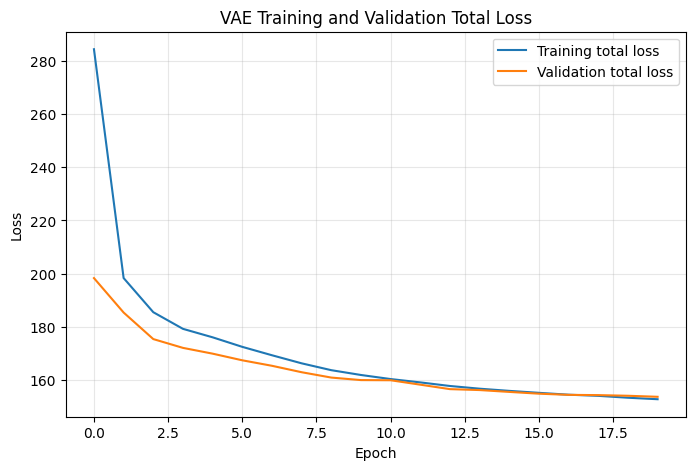

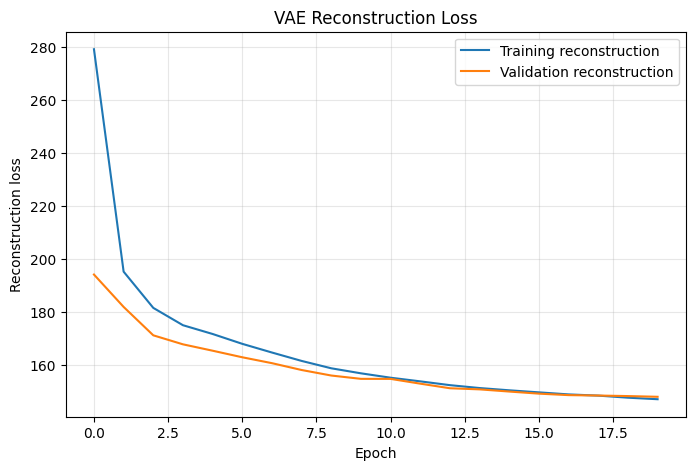

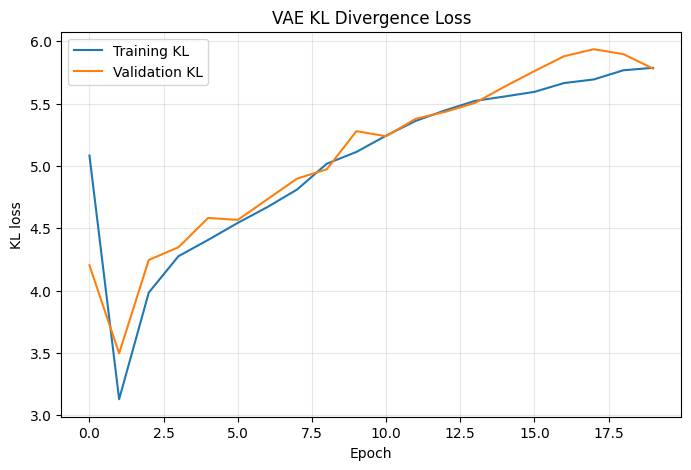

In [ ]:
# ============================================================
# 21. PLOT 9 – VAE LOSSES
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_vae.history["loss"], label="Training total loss")
if "val_loss" in history_vae.history:
    ax.plot(history_vae.history["val_loss"], label="Validation total loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("VAE Training and Validation Total Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_vae.history["reconstruction_loss"], label="Training reconstruction")
if "val_reconstruction_loss" in history_vae.history:
    ax.plot(history_vae.history["val_reconstruction_loss"], label="Validation reconstruction")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction loss")
ax.set_title("VAE Reconstruction Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_vae.history["kl_loss"], label="Training KL")
if "val_kl_loss" in history_vae.history:
    ax.plot(history_vae.history["val_kl_loss"], label="Validation KL")
ax.set_xlabel("Epoch")
ax.set_ylabel("KL loss")
ax.set_title("VAE KL Divergence Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

,Reconstruction Loss,KL Loss,Total Loss,Test MSE,Test MAE,Mean SSIM
0,147.932495,5.78929,153.721771,0.043461,0.101265,0.492679


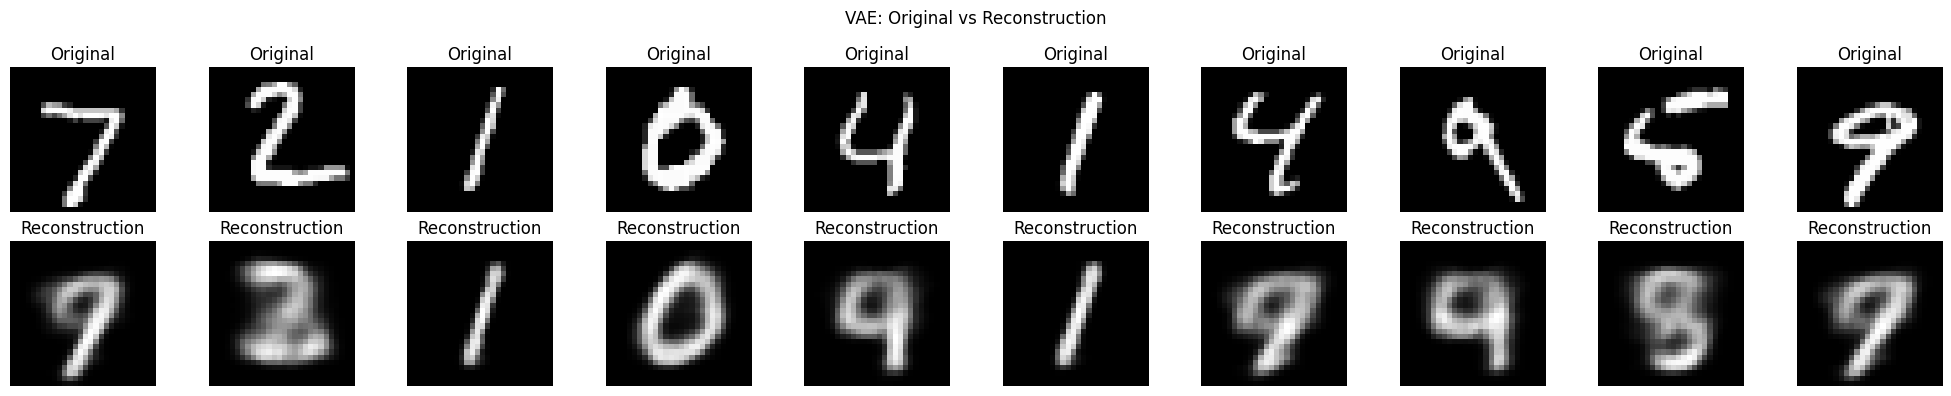

In [ ]:
# ============================================================
# 22. VAE RECONSTRUCTION + METRICS
# ============================================================
z_mean_test, z_log_var_test = vae.encode(x_test_img, training=False)
z_test = vae.reparameterize(z_mean_test, z_log_var_test)
vae_recon = vae.decode(z_test, training=False).numpy()

vae_image_metrics = calculate_metrics(x_test_img, vae_recon)

# Evaluate once so the metric objects contain current test losses
vae_test_eval = vae.evaluate(x_test_img, x_test_img, verbose=0, return_dict=True)

vae_metrics_df = pd.DataFrame([{
    "Reconstruction Loss": vae_test_eval["reconstruction_loss"],
    "KL Loss": vae_test_eval["kl_loss"],
    "Total Loss": vae_test_eval["loss"],
    "Test MSE": vae_image_metrics["MSE"],
    "Test MAE": vae_image_metrics["MAE"],
    "Mean SSIM": vae_image_metrics["SSIM"]
}])

display(vae_metrics_df)

plot_reconstructions(
    x_test_img,
    vae_recon,
    n=10,
    title="VAE: Original vs Reconstruction"
)

### Reparameterization trick demonstration

In [ ]:
# ============================================================
# 23. REPARAMETERIZATION DEMONSTRATION
# ============================================================
sample_mean = z_mean_test[:1].numpy()
sample_log_var = z_log_var_test[:1].numpy()
sample_sigma = np.exp(0.5 * sample_log_var)
sample_epsilon = np.random.randn(1, 2)
sample_z = sample_mean + sample_sigma * sample_epsilon

print("μ =", sample_mean)
print("log σ² =", sample_log_var)
print("σ =", sample_sigma)
print("ε =", sample_epsilon)
print("z = μ + σ * ε =", sample_z)

μ = [[0.97909915 0.8953894 ]]
log σ² = [[-5.6809564 -5.4435215]]
σ = [[0.05839774 0.06575887]]
ε = [[ 0.11810213 -0.68075415]]
z = μ + σ * ε = [[0.98599605 0.85062376]]


# Part E – VAE latent space

Because the VAE latent dimension is 2, each test image can be represented by a point `(z1, z2)`.
The labels are used **only for visualization**, not as training targets.

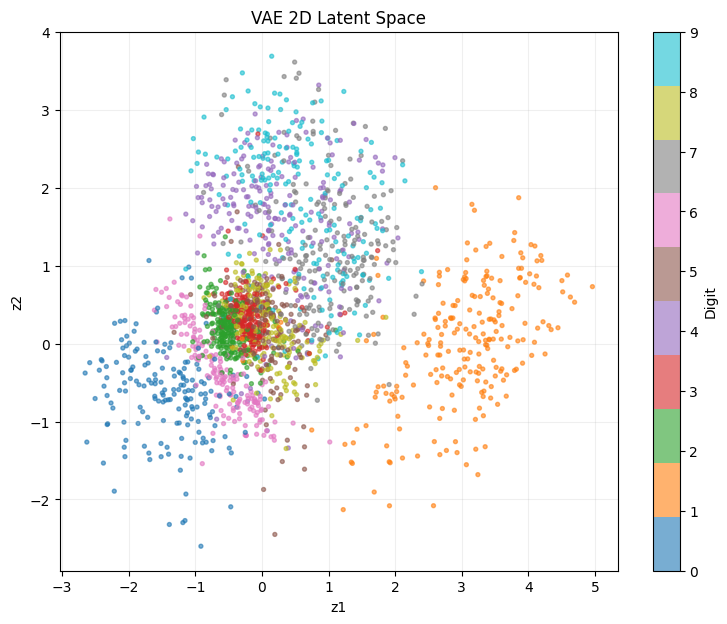

In [ ]:
# ============================================================
# 24. PLOT 6 – VAE LATENT SPACE
# ============================================================
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=8,
    alpha=0.6
)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("VAE 2D Latent Space")
plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.grid(alpha=0.2)
plt.show()

### Plot 7 – Randomly generated VAE images

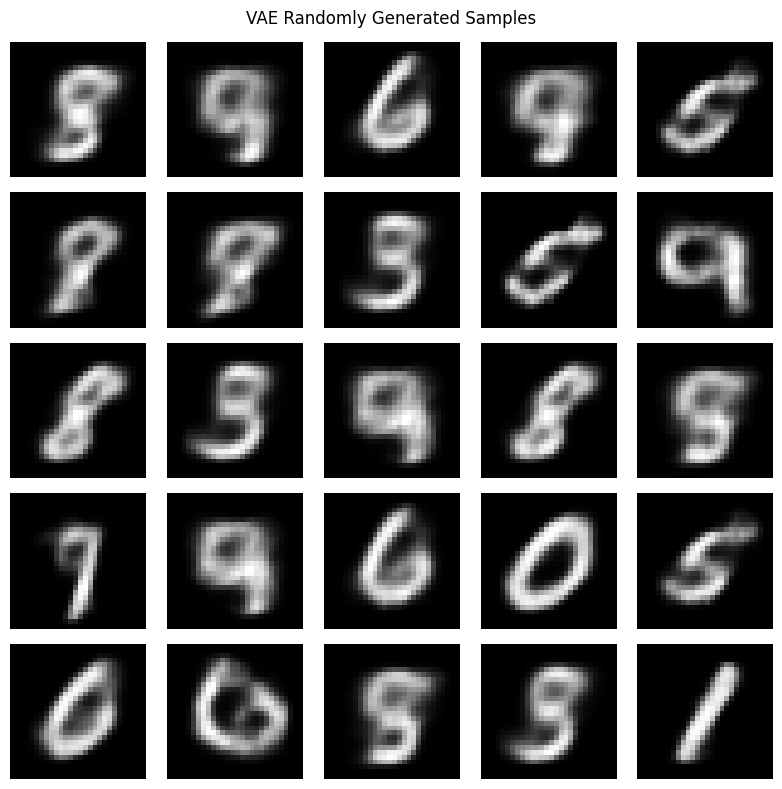

In [ ]:
# ============================================================
# 25. PLOT 7 – GENERATE AT LEAST 25 NEW IMAGES
# ============================================================
NUM_GENERATED = 25

random_latents = np.random.normal(
    size=(NUM_GENERATED, 2)
).astype("float32")

generated_images = vae.decode(random_latents, training=False).numpy()

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(generated_images[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.suptitle("VAE Randomly Generated Samples")
plt.tight_layout()
plt.show()

### Plot 8 – Latent-space interpolation

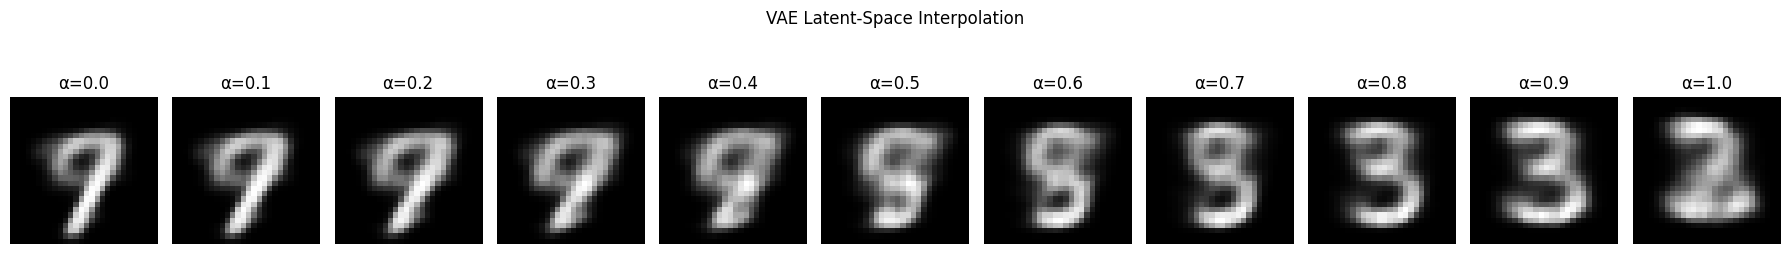

In [ ]:
# ============================================================
# 26. PLOT 8 – LATENT SPACE INTERPOLATION
# ============================================================
# Pick two encoded test samples
zA = z_mean_test[0].numpy()
zB = z_mean_test[1].numpy()

alphas = np.arange(0.0, 1.01, 0.1)
interpolated_latents = np.array([
    (1 - alpha) * zA + alpha * zB
    for alpha in alphas
], dtype="float32")

interpolated_images = vae.decode(
    interpolated_latents,
    training=False
).numpy()

fig, axes = plt.subplots(1, len(alphas), figsize=(18, 3))
for i, (alpha, ax) in enumerate(zip(alphas, axes)):
    ax.imshow(interpolated_images[i].squeeze(), cmap="gray")
    ax.set_title(f"α={alpha:.1f}")
    ax.axis("off")

plt.suptitle("VAE Latent-Space Interpolation")
plt.tight_layout()
plt.show()

# Part F – Reconstruction-error distribution and high-error analysis

Per-image reconstruction error:

**eᵢ = (1/D) Σⱼ (xᵢⱼ − x̂ᵢⱼ)²**

We use the CAE for the reconstruction-error analysis.

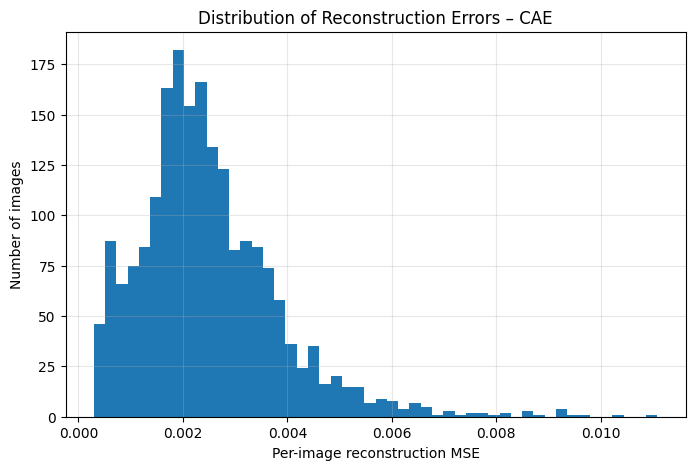

Minimum error: 0.00029564975
Maximum error: 0.01108484
Mean error: 0.0024996102
Median error: 0.0022874228


In [ ]:
# ============================================================
# 27. PLOT 10 / REQUIRED ERROR DISTRIBUTION
# ============================================================
cae_errors = per_image_mse(x_test_img, cae_recon)

plt.figure(figsize=(8, 5))
plt.hist(cae_errors, bins=50)
plt.xlabel("Per-image reconstruction MSE")
plt.ylabel("Number of images")
plt.title("Distribution of Reconstruction Errors – CAE")
plt.grid(alpha=0.3)
plt.show()

print("Minimum error:", cae_errors.min())
print("Maximum error:", cae_errors.max())
print("Mean error:", cae_errors.mean())
print("Median error:", np.median(cae_errors))

,Rank,Test Index,Digit,Reconstruction MSE
0,1,895,0,0.011085
1,2,1526,0,0.010308
2,3,1908,6,0.009774
3,4,193,9,0.009424
4,5,431,8,0.009349


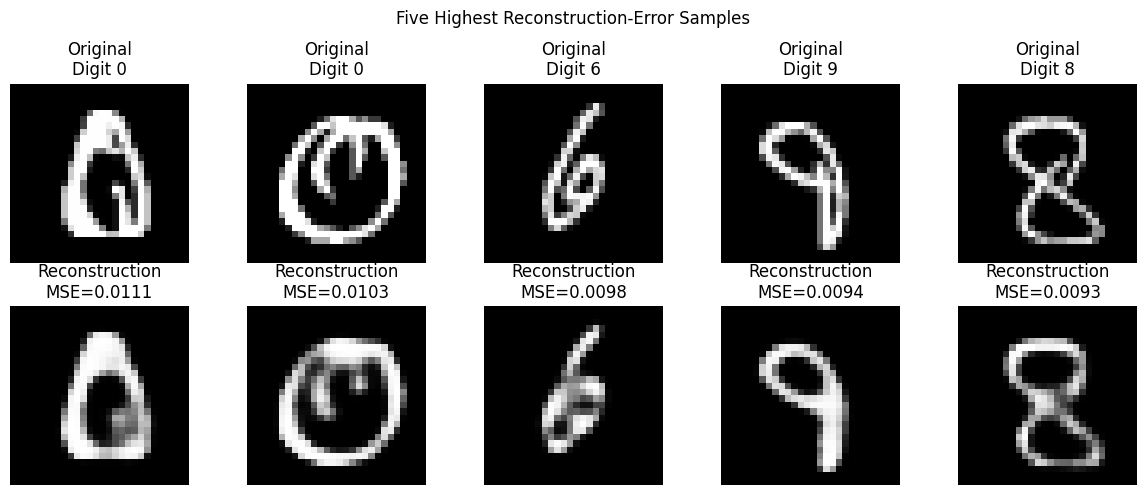

In [ ]:
# ============================================================
# 28. TOP-5 HIGH-ERROR TEST IMAGES
# ============================================================
top5_indices = np.argsort(cae_errors)[-5:][::-1]

high_error_table = pd.DataFrame({
    "Rank": np.arange(1, 6),
    "Test Index": top5_indices,
    "Digit": y_test[top5_indices],
    "Reconstruction MSE": cae_errors[top5_indices]
})
display(high_error_table)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for col, idx in enumerate(top5_indices):
    axes[0, col].imshow(x_test_img[idx].squeeze(), cmap="gray")
    axes[0, col].set_title(f"Original\nDigit {y_test[idx]}")
    axes[0, col].axis("off")

    axes[1, col].imshow(cae_recon[idx].squeeze(), cmap="gray")
    axes[1, col].set_title(f"Reconstruction\nMSE={cae_errors[idx]:.4f}")
    axes[1, col].axis("off")

plt.suptitle("Five Highest Reconstruction-Error Samples")
plt.tight_layout()
plt.show()

### High-error interpretation

Inspect the five images above and explain whether the high error is associated with:
- unusual handwriting
- thicker/thinner strokes
- tilted or shifted digits
- ambiguous digit shapes
- unusual spacing or structure
- blurred or noisy visual patterns

Do not claim a cause that is not visible in the displayed examples.

# Part G – Consolidated comparison of reconstruction models

In [ ]:
# ============================================================
# 29. CONSOLIDATED RESULTS TABLE
# ============================================================
consolidated_results = pd.DataFrame([
    make_results_row("FC Autoencoder", fc_autoencoder, x_test_img, fc_recon, fc_time),
    make_results_row("Conv. Autoencoder", cae, x_test_img, cae_recon, cae_time),
    make_results_row("Denoising CAE", denoise_cae, x_test_img, denoised_recon, denoise_time),
    {
        "Model": "VAE",
        "MSE": vae_image_metrics["MSE"],
        "MAE": vae_image_metrics["MAE"],
        "SSIM": vae_image_metrics["SSIM"],
        "Parameters": vae.count_params(),
        "Time (sec)": vae_time
    }
])

display(consolidated_results)

,Model,MSE,MAE,SSIM,Parameters,Time (sec)
0,FC Autoencoder,0.020513,0.054925,0.756392,211040,29.089839
1,Conv. Autoencoder,0.002500,0.014853,0.974801,74497,20.866997
2,Denoising CAE,0.004944,0.021824,0.941974,74497,18.342228
3,VAE,0.043461,0.101265,0.492679,485957,26.737421


## VAE-specific loss table

In [ ]:
# ============================================================
# 30. VAE-SPECIFIC RESULTS
# ============================================================
display(vae_metrics_df)

,Reconstruction Loss,KL Loss,Total Loss,Test MSE,Test MAE,Mean SSIM
0,147.932495,5.78929,153.721771,0.043461,0.101265,0.492679


# Part H – Additional Latent-Dimension Study for the Fully Connected AE

Required latent dimensions:

**dz ∈ {2, 8, 16, 32}**

Report:
- latent dimension
- MSE
- SSIM
- parameters

Plot latent dimension versus reconstruction MSE.

In [ ]:
# ============================================================
# 31. FC-AE LATENT-DIMENSION STUDY
# ============================================================
def build_fc_autoencoder(latent_dim):
    encoder = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(latent_dim)
    ])

    decoder = keras.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(784, activation="sigmoid")
    ])

    model = keras.Sequential([encoder, decoder])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy"
    )
    return model


latent_dimensions = [2, 8, 16, 32]
latent_study_results = []
latent_study_models = {}

for dz in latent_dimensions:
    print(f"\nTraining FC-AE with latent dimension = {dz}")

    model = build_fc_autoencoder(dz)

    start = time.time()
    hist = model.fit(
        x_train_flat,
        x_train_flat,
        validation_data=(x_test_flat, x_test_flat),
        epochs=20,
        batch_size=128,
        shuffle=True,
        verbose=0
    )
    elapsed = time.time() - start

    recon_flat = model.predict(x_test_flat, verbose=0)
    recon_img = recon_flat.reshape(-1, 28, 28, 1)
    metrics = calculate_metrics(x_test_img, recon_img)

    latent_study_models[dz] = (model, hist, recon_img)

    latent_study_results.append({
        "Latent Dimension": dz,
        "MSE": metrics["MSE"],
        "SSIM": metrics["SSIM"],
        "Parameters": model.count_params(),
        "Time (sec)": elapsed
    })

latent_study_df = pd.DataFrame(latent_study_results)
display(latent_study_df)


Training FC-AE with latent dimension = 2

Training FC-AE with latent dimension = 8

Training FC-AE with latent dimension = 16

Training FC-AE with latent dimension = 32


,Latent Dimension,MSE,SSIM,Parameters,Time (sec)
0,2,0.044417,0.478543,210130,11.680726
1,8,0.025716,0.698683,210520,11.594530
2,16,0.021902,0.739577,211040,11.285339
3,32,0.020561,0.753548,212080,11.455786


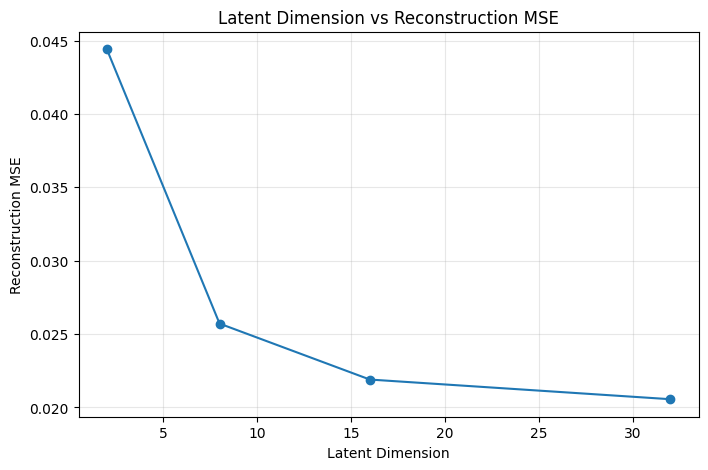

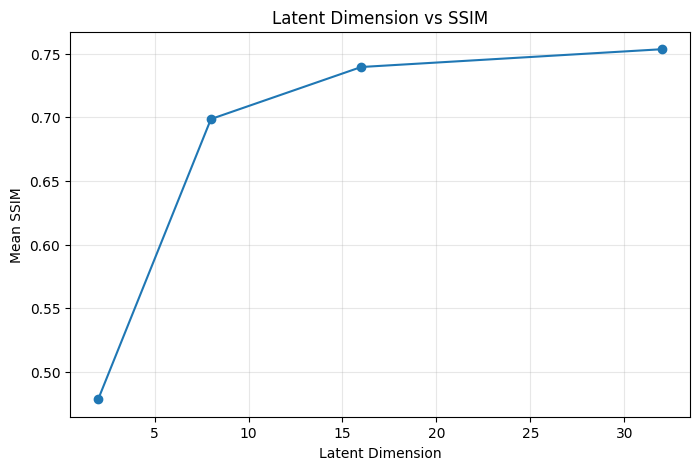

In [ ]:
# Plot 10 – Latent dimension vs MSE
plt.figure(figsize=(8, 5))
plt.plot(
    latent_study_df["Latent Dimension"],
    latent_study_df["MSE"],
    marker="o"
)
plt.xlabel("Latent Dimension")
plt.ylabel("Reconstruction MSE")
plt.title("Latent Dimension vs Reconstruction MSE")
plt.grid(alpha=0.3)
plt.show()

# Also visualize SSIM
plt.figure(figsize=(8, 5))
plt.plot(
    latent_study_df["Latent Dimension"],
    latent_study_df["SSIM"],
    marker="o"
)
plt.xlabel("Latent Dimension")
plt.ylabel("Mean SSIM")
plt.title("Latent Dimension vs SSIM")
plt.grid(alpha=0.3)
plt.show()

# Part I – Additional Exercise 1
## Convolutional autoencoder with latent dimensions 4, 8, 16 and 32

For a convolutional model, "latent dimension" is implemented here as the number of channels in the bottleneck feature map. The spatial bottleneck remains 7×7.

In [ ]:
# ============================================================
# 32. CAE BOTTLENECK CHANNEL STUDY: 4, 8, 16, 32
# ============================================================

cae_latent_channels = [4, 8, 16, 32]
cae_latent_results = []

for dz in cae_latent_channels:
    print(f"\nTraining CAE with bottleneck channels = {dz}")

    # Build model
    model = build_cae(dz)

    # IMPORTANT: compile before model.fit()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy"
    )

    start = time.time()

    hist = model.fit(
        x_train_img,
        x_train_img,
        validation_data=(x_test_img, x_test_img),
        epochs=20,
        batch_size=128,
        shuffle=True,
        verbose=1
    )

    elapsed = time.time() - start

    # Reconstruction
    recon = model.predict(x_test_img, verbose=0)

    # Metrics
    metrics = calculate_metrics(
        x_test_img,
        recon
    )

    # Store results
    cae_latent_results.append({
        "CAE Bottleneck Channels": dz,
        "MSE": metrics["MSE"],
        "MAE": metrics["MAE"],
        "SSIM": metrics["SSIM"],
        "Parameters": model.count_params(),
        "Time (sec)": elapsed
    })

# Convert results to DataFrame
cae_latent_df = pd.DataFrame(cae_latent_results)

display(cae_latent_df)


Training CAE with bottleneck channels = 4
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.4298 - val_loss: 0.1999
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1613 - val_loss: 0.1352
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1285 - val_loss: 0.1202
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1171 - val_loss: 0.1112
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1099 - val_loss: 0.1051
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1052 - val_loss: 0.1013
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1022 - val_loss: 0.0988
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0998 - val_loss: 0.0966
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0976 - val_loss: 0.0946
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0948 - val_loss: 0.0916
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0920 - val_loss: 0.0899
Epoch 12/20
79/79 ━━━━━━━━━━━

,CAE Bottleneck Channels,MSE,MAE,SSIM,Parameters,Time (sec)
0,4,0.007356,0.027057,0.925273,3097,22.137658
1,8,0.005611,0.023019,0.942876,5841,18.703304
2,16,0.003957,0.018719,0.960647,12193,17.538725
3,32,0.003179,0.016752,0.967542,28353,19.235285


# Part J – Additional Exercise 4
## Replace the convolutional decoder with transposed convolutions

This version explicitly uses `Conv2DTranspose` instead of `UpSampling2D`.

Transposed-convolution CAE metrics:


,MSE,MAE,SSIM
0,0.002349,0.014367,0.975462


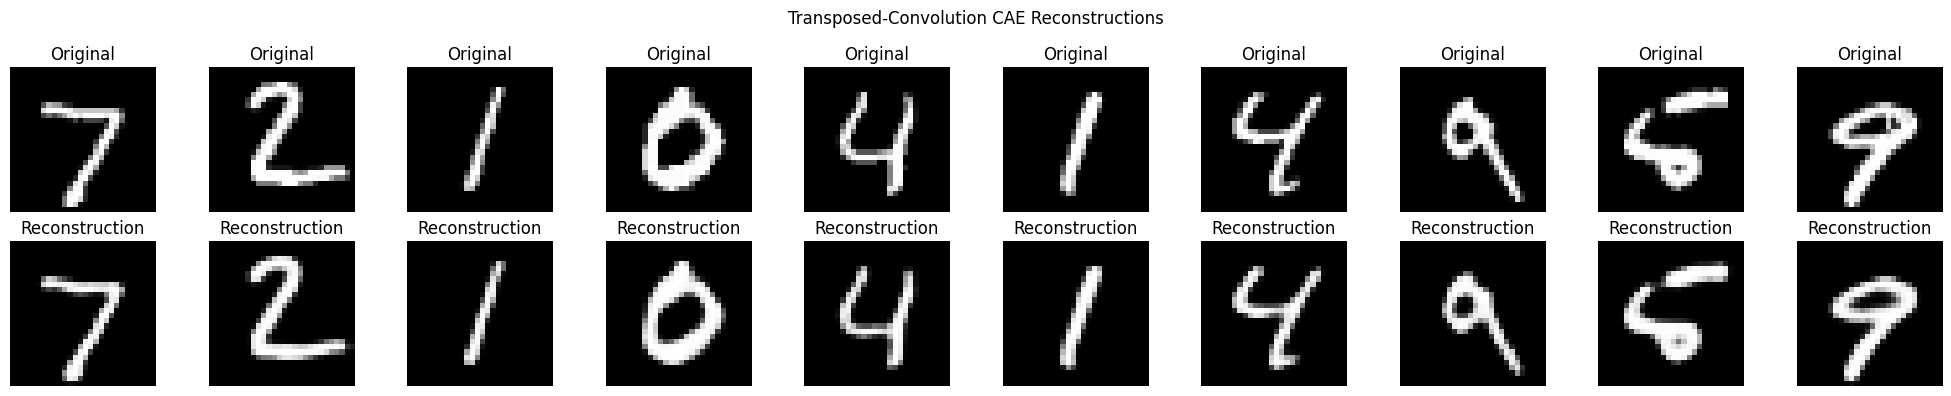

In [ ]:
# ============================================================
# 33. TRANSPOSED-CONVOLUTION DECODER CAE
# ============================================================
def build_transpose_cae():
    inputs = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

    x = layers.Conv2DTranspose(
        32, 3, strides=2, activation="relu", padding="same"
    )(x)
    x = layers.Conv2DTranspose(
        16, 3, strides=2, activation="relu", padding="same"
    )(x)

    outputs = layers.Conv2D(
        1, 3, activation="sigmoid", padding="same"
    )(x)

    model = keras.Model(inputs, outputs, name="Transpose_CAE")
    return model


transpose_cae = build_transpose_cae()
transpose_cae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

start_time = time.time()
history_transpose = transpose_cae.fit(
    x_train_img,
    x_train_img,
    validation_data=(x_test_img, x_test_img),
    epochs=20,
    batch_size=128,
    verbose=0
)
transpose_time = time.time() - start_time

transpose_recon = transpose_cae.predict(x_test_img, verbose=0)
transpose_metrics = calculate_metrics(x_test_img, transpose_recon)

print("Transposed-convolution CAE metrics:")
display(pd.DataFrame([transpose_metrics]))

plot_reconstructions(
    x_test_img,
    transpose_recon,
    n=10,
    title="Transposed-Convolution CAE Reconstructions"
)

# Part K – Additional Exercise 5
## VAE with latent dimension 8

This uses the same VAE implementation but changes the latent dimensionality from 2 to 8.

In [ ]:
# ============================================================
# 34. VAE LATENT DIMENSION 8
# ============================================================
vae8 = VAE(latent_dim=8, kl_weight=1.0, name="VAE_latent_8")
vae8.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
_ = vae8(x_train_img[:2])

start_time = time.time()
history_vae8 = vae8.fit(
    x_train_img,
    x_train_img,
    validation_data=(x_test_img, x_test_img),
    epochs=20,
    batch_size=128,
    verbose=0
)
vae8_time = time.time() - start_time

z8_mean, z8_log_var = vae8.encode(x_test_img, training=False)
z8 = vae8.reparameterize(z8_mean, z8_log_var)
vae8_recon = vae8.decode(z8, training=False).numpy()
vae8_metrics = calculate_metrics(x_test_img, vae8_recon)

display(pd.DataFrame([{
    "VAE Latent Dim": 8,
    "MSE": vae8_metrics["MSE"],
    "MAE": vae8_metrics["MAE"],
    "SSIM": vae8_metrics["SSIM"],
    "Parameters": vae8.count_params(),
    "Time (sec)": vae8_time
}]))

,VAE Latent Dim,MSE,MAE,SSIM,Parameters,Time (sec)
0,8,0.02134,0.05483,0.770269,506321,24.871655


# Part L – Additional Exercise 6
## Investigate the effect of KL-loss contribution

We compare different KL weights. This is an experimental extension. Larger KL weight forces the approximate posterior more strongly toward the N(0, I) prior and can change reconstruction quality.

In [ ]:
# ============================================================
# 35. KL-WEIGHT STUDY
# ============================================================
kl_weights = [0.1, 0.5, 1.0, 2.0]
kl_results = []

for weight in kl_weights:
    print(f"\nTraining VAE with KL weight = {weight}")

    model = VAE(latent_dim=2, kl_weight=weight, name=f"VAE_KL_{weight}")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
    _ = model(x_train_img[:2])

    start = time.time()
    hist = model.fit(
        x_train_img,
        x_train_img,
        validation_data=(x_test_img, x_test_img),
        epochs=20,
        batch_size=128,
        verbose=0
    )
    elapsed = time.time() - start

    zm, zlv = model.encode(x_test_img, training=False)
    z = model.reparameterize(zm, zlv)
    recon = model.decode(z, training=False).numpy()

    metrics = calculate_metrics(x_test_img, recon)
    eval_dict = model.evaluate(
        x_test_img,
        x_test_img,
        verbose=0,
        return_dict=True
    )

    kl_results.append({
        "KL Weight": weight,
        "MSE": metrics["MSE"],
        "MAE": metrics["MAE"],
        "SSIM": metrics["SSIM"],
        "Reconstruction Loss": eval_dict["reconstruction_loss"],
        "KL Loss": eval_dict["kl_loss"],
        "Total Loss": eval_dict["loss"],
        "Time (sec)": elapsed
    })

kl_results_df = pd.DataFrame(kl_results)
display(kl_results_df)


Training VAE with KL weight = 0.1

Training VAE with KL weight = 0.5

Training VAE with KL weight = 1.0

Training VAE with KL weight = 2.0


,KL Weight,MSE,MAE,SSIM,Reconstruction Loss,KL Loss,Total Loss,Time (sec)
0,0.1,0.044458,0.104960,0.482556,150.180710,10.014761,151.182190,24.769822
1,0.5,0.044786,0.102817,0.489676,150.526825,7.150173,154.101929,23.969284
2,1.0,0.043505,0.100749,0.493567,148.326492,6.093962,154.420486,23.747373
3,2.0,0.045070,0.105888,0.472117,151.891800,4.647018,161.185852,26.126067


# Part M – Additional Exercise 7
## Generate a larger VAE sample grid

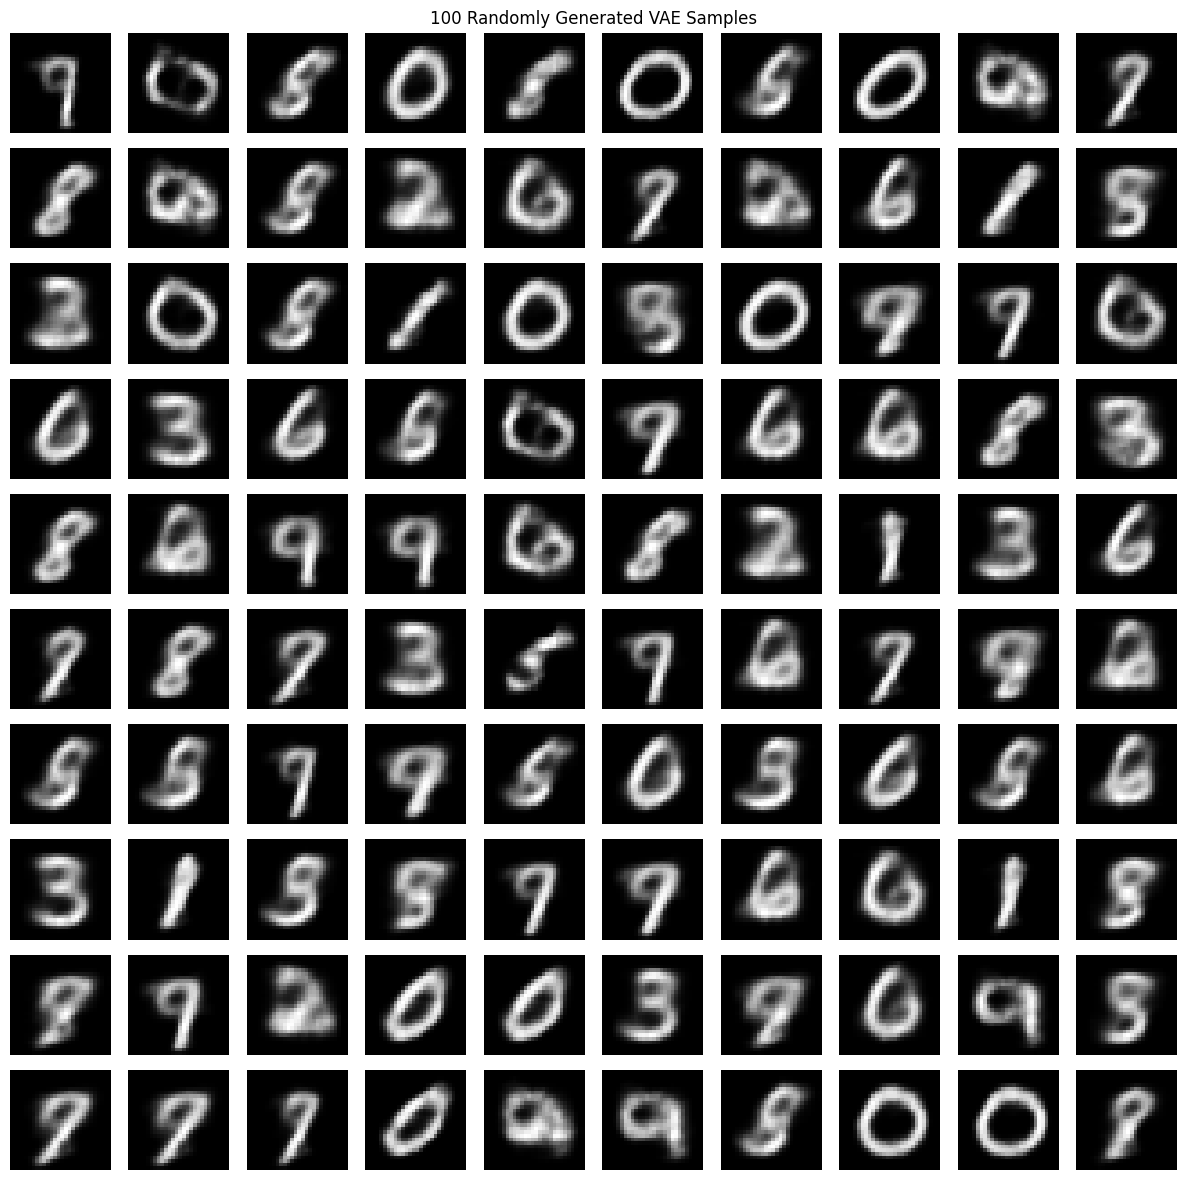

In [ ]:
# ============================================================
# 36. LARGER VAE GENERATION GRID
# ============================================================
NUM_LARGE = 100
large_latents = np.random.normal(size=(NUM_LARGE, 2)).astype("float32")
large_samples = vae.decode(large_latents, training=False).numpy()

fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(large_samples[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.suptitle("100 Randomly Generated VAE Samples")
plt.tight_layout()
plt.show()

# Part N – Additional Exercise 2
## Compare Gaussian noise and salt-and-pepper noise using the same denoising architecture

The two models above use the same CAE architecture. The only difference is the corruption process.

In [ ]:
# ============================================================
# 37. SIDE-BY-SIDE NOISE COMPARISON
# ============================================================
comparison_noise = pd.DataFrame({
    "Noise": ["Gaussian", "Salt-and-Pepper"],
    "Level": [0.2, 0.10],
    "MSE": [
        gaussian_results_df.loc[gaussian_results_df["Gaussian Sigma"] == 0.2, "MSE"].iloc[0],
        sp_results_df.loc[sp_results_df["Salt-Pepper p"] == 0.10, "MSE"].iloc[0]
    ],
    "MAE": [
        gaussian_results_df.loc[gaussian_results_df["Gaussian Sigma"] == 0.2, "MAE"].iloc[0],
        sp_results_df.loc[sp_results_df["Salt-Pepper p"] == 0.10, "MAE"].iloc[0]
    ],
    "SSIM": [
        gaussian_results_df.loc[gaussian_results_df["Gaussian Sigma"] == 0.2, "SSIM"].iloc[0],
        sp_results_df.loc[sp_results_df["Salt-Pepper p"] == 0.10, "SSIM"].iloc[0]
    ]
})

display(comparison_noise)

,Noise,Level,MSE,MAE,SSIM
0,Gaussian,0.2,0.004984,0.021911,0.941646
1,Salt-and-Pepper,0.1,0.004772,0.020922,0.946044


# Part O – Additional Exercise 3
## Train with two different noise levels and compare SSIM

This section uses the Gaussian-noise denoising setup and trains two separate models.

In [ ]:
# ============================================================
# 38. TRAIN TWO DENOISING MODELS AT DIFFERENT NOISE LEVELS
# ============================================================
two_noise_levels = [0.1, 0.3]
two_noise_results = []

for sigma in two_noise_levels:
    print(f"Training denoising model for sigma={sigma}")

    train_noisy = add_gaussian_noise(x_train_img, sigma)
    test_noisy = add_gaussian_noise(x_test_img, sigma)

    model = build_cae(64)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy"
    )

    start = time.time()
    model.fit(
        train_noisy,
        x_train_img,
        validation_data=(test_noisy, x_test_img),
        epochs=20,
        batch_size=128,
        verbose=0
    )
    elapsed = time.time() - start

    recon = model.predict(test_noisy, verbose=0)
    metrics = calculate_metrics(x_test_img, recon)

    two_noise_results.append({
        "Training Gaussian Sigma": sigma,
        "MSE": metrics["MSE"],
        "MAE": metrics["MAE"],
        "SSIM": metrics["SSIM"],
        "Time (sec)": elapsed
    })

two_noise_df = pd.DataFrame(two_noise_results)
display(two_noise_df)

Training denoising model for sigma=0.1
Training denoising model for sigma=0.3


,Training Gaussian Sigma,MSE,MAE,SSIM,Time (sec)
0,0.1,0.003273,0.017445,0.963322,19.452458
1,0.3,0.006707,0.026288,0.918279,18.933332


# Part P – Export all important results

This cell saves the quantitative results as CSV files so they can be directly used while preparing the lab report.

In [ ]:
# ============================================================
# 39. EXPORT RESULTS
# ============================================================
output_dir = "/content/experiment7_results"
os.makedirs(output_dir, exist_ok=True)

consolidated_results.to_csv(
    os.path.join(output_dir, "consolidated_model_results.csv"),
    index=False
)

gaussian_results_df.to_csv(
    os.path.join(output_dir, "gaussian_noise_results.csv"),
    index=False
)

sp_results_df.to_csv(
    os.path.join(output_dir, "salt_pepper_results.csv"),
    index=False
)

latent_study_df.to_csv(
    os.path.join(output_dir, "fc_latent_dimension_results.csv"),
    index=False
)

cae_latent_df.to_csv(
    os.path.join(output_dir, "cae_latent_dimension_results.csv"),
    index=False
)

kl_results_df.to_csv(
    os.path.join(output_dir, "kl_weight_results.csv"),
    index=False
)

print("Results saved in:", output_dir)
print(os.listdir(output_dir))

Results saved in: /content/experiment7_results
['consolidated_model_results.csv', 'gaussian_noise_results.csv', 'kl_weight_results.csv', 'cae_latent_dimension_results.csv', 'salt_pepper_results.csv', 'fc_latent_dimension_results.csv']
